<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/dengue_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dengue Fever Hematological Dataset.csv')

## **Data Introduce**

In [49]:
# Check data
print(df.head())
print(df.shape)  # How many rows and columns
print(df.columns.tolist())  # Column names

   Gender  Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
0    Male   21              14.8              48              47   
1    Male   30              15.0              47              49   
2    Male   51              16.3              41              48   
3  Female   26              12.3              46              49   
4    Male   35              16.1              45              46   

   Monocytes(%)  Eosinophils(%)  RBC  HCT(%)  MCV(fl)  MCH(pg)  MCHC(g/dl)  \
0             3               2    5   48.00     96.0    29.60        30.8   
1             6               3    5   49.80     96.1    28.40        29.5   
2             4               5    5   50.10     93.5    31.30        32.7   
3             7               5    5   44.00     90.0    30.50        30.5   
4             4               4    5   50.53     91.0    29.12        29.2   

   RDW-CV(%)  Total Platelet Count(/cumm)  MPV(fl)  PDW(%)  PCT(%)  \
0       11.6                       112000    10.70  

In [50]:
print("\nDataFrame Description:")
print(df.describe())


DataFrame Description:
               Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
count  1523.000000       1523.000000     1523.000000     1523.000000   
mean     40.310571         14.513451       44.484570       43.559422   
std      15.286190          1.627142        4.344736        4.972815   
min       5.000000         10.400000       29.000000       29.000000   
25%      28.000000         13.200000       42.000000       41.000000   
50%      39.000000         14.600000       45.000000       44.000000   
75%      53.000000         15.800000       48.000000       47.000000   
max      78.000000         17.500000       60.000000       56.000000   

       Monocytes(%)  Eosinophils(%)          RBC       HCT(%)      MCV(fl)  \
count   1523.000000     1523.000000  1523.000000  1523.000000  1523.000000   
mean       3.270519        3.083388     4.765594    45.189280    89.815561   
std        1.209507        1.000791     0.722874     3.566435     5.515619   
min        2.00

In [51]:
# Basic DataFrame information
print("\nDataFrame Info:")
print(df.info())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       1523 non-null   object 
 1   Age                          1523 non-null   int64  
 2   Hemoglobin(g/dl)             1523 non-null   float64
 3   Neutrophils(%)               1523 non-null   int64  
 4   Lymphocytes(%)               1523 non-null   int64  
 5   Monocytes(%)                 1523 non-null   int64  
 6   Eosinophils(%)               1523 non-null   int64  
 7   RBC                          1523 non-null   int64  
 8   HCT(%)                       1523 non-null   float64
 9   MCV(fl)                      1523 non-null   float64
 10  MCH(pg)                      1523 non-null   float64
 11  MCHC(g/dl)                   1523 non-null   float64
 12  RDW-CV(%)                    1523 non-null   float64
 13  T

In [52]:
# Display last 5 rows
print("\nLast 5 rows of the dataset:")
print(df.tail())
# Check data types
print("\nData Types:")
print(df.dtypes)


Last 5 rows of the dataset:
      Gender  Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
1518  Female   54              17.2              41              48   
1519    Male   23              16.8              47              40   
1520    Male   24              15.9              46              46   
1521    Male   49              13.2              41              49   
1522    Male   49              13.2              41              44   

      Monocytes(%)  Eosinophils(%)  RBC  HCT(%)  MCV(fl)  MCH(pg)  MCHC(g/dl)  \
1518             3               3    5   41.97     87.9     26.6        30.1   
1519             4               3    4   38.00     99.2     32.6        33.6   
1520             2               4    4   39.78     88.3     29.9        34.2   
1521             2               3    5   51.07     92.0     32.8        32.0   
1522             2               3    5   50.14     94.2     30.8        32.2   

      RDW-CV(%)  Total Platelet Count(/cumm)  MPV(fl)  PD

Result
positive    1042
negative     481
Name: count, dtype: int64


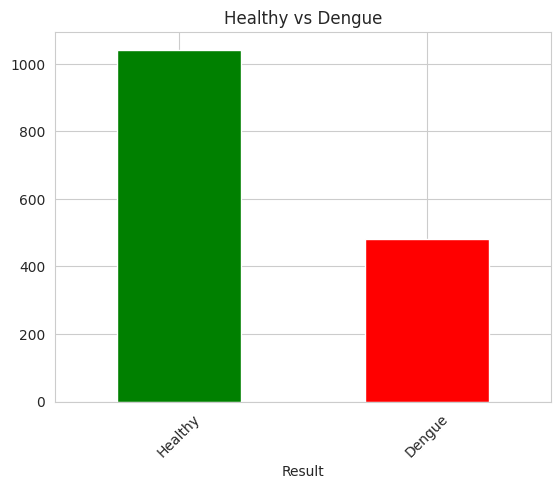

In [86]:
# Show distribution
print(df['Result'].value_counts())

# Plot
df['Result'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Healthy vs Dengue')
plt.xticks([0, 1], ['Healthy', 'Dengue'], rotation=45)
plt.show()

## **Encoding**

In [54]:
from sklearn.preprocessing import LabelEncoder

# For yes/no or male/female (2 categories only)
label_encoder = LabelEncoder()

In [55]:
# Convert 'smoker' column
df['Result_encoded'] = label_encoder.fit_transform(df['Result'])
print("\nAfter Label Encoding 'Result':")
print(df[['Result', 'Result_encoded']])
# no = 0, yes = 1

# Convert 'gender' column
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
print("\nAfter Label Encoding 'Gender':")
print(df[['Gender', 'Gender_encoded']])
# female = 0, male = 1


After Label Encoding 'Result':
        Result  Result_encoded
0     positive               1
1     positive               1
2     negative               0
3     negative               0
4     negative               0
...        ...             ...
1518  positive               1
1519  positive               1
1520  positive               1
1521  positive               1
1522  positive               1

[1523 rows x 2 columns]

After Label Encoding 'Gender':
      Gender  Gender_encoded
0       Male               1
1       Male               1
2       Male               1
3     Female               0
4       Male               1
...      ...             ...
1518  Female               0
1519    Male               1
1520    Male               1
1521    Male               1
1522    Male               1

[1523 rows x 2 columns]


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## **Train and Test**

In [103]:
# Separate input (X) and output (y)
X = df.drop(['Gender','Result','Result_encoded','Lymphocytes(%)','RDW-CV(%)','MCHC(g/dl)','PDW(%)','Total WBC count(/cumm)'], axis=1)  # Everything except Outcome
y = df['Result_encoded']                # Only Outcome

print("X has all patient information (18 columns)")
print("y has dengue yes/no (1 column)")

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for test
    random_state=20   # Same result every time
)

print(f"\nWe will train with: {len(X_train)} patients")
print(f"We will test with: {len(X_test)} patients")

X has all patient information (18 columns)
y has dengue yes/no (1 column)

We will train with: 1218 patients
We will test with: 305 patients


**StandarScalling**

In [104]:
# Create scaler
scaler = StandardScaler()

# Learn from training data and scale it
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data (just transform, don't fit)
X_test_scaled = scaler.transform(X_test)

print("\nAfter scaling:")
print("All features now have similar range!")
print(f"Example - First patient's Age before scaling: {X_train.values[0][7]}")
print(f"Example - First patient's Age after scaling: {X_train_scaled[0][7]:.2f}")


After scaling:
All features now have similar range!
Example - First patient's Age before scaling: 85.4
Example - First patient's Age after scaling: -0.79


## **Model- KNN**

Best K: 5


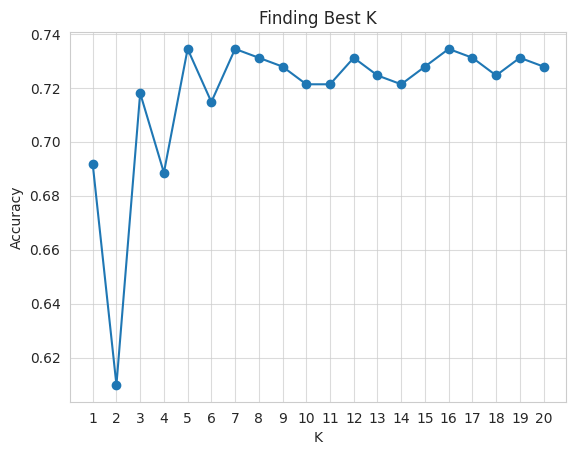

In [105]:
# Find best K
accuracies = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k}")

# Plot
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.title('Finding Best K')
plt.grid(alpha=0.7)

plt.show()

In [106]:
# Train final KNN model
print(f"\n🤖 Training KNN with K = {best_k}...\n")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("✅ KNN Model trained!")
print(f"\n📊 KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")


🤖 Training KNN with K = 5...

✅ KNN Model trained!

📊 KNN Accuracy: 0.7344 (73.44%)



📋 KNN Classification Report:
              precision    recall  f1-score   support

     Healthy       0.68      0.40      0.50       103
      Dengue       0.75      0.91      0.82       202

    accuracy                           0.73       305
   macro avg       0.72      0.65      0.66       305
weighted avg       0.73      0.73      0.71       305



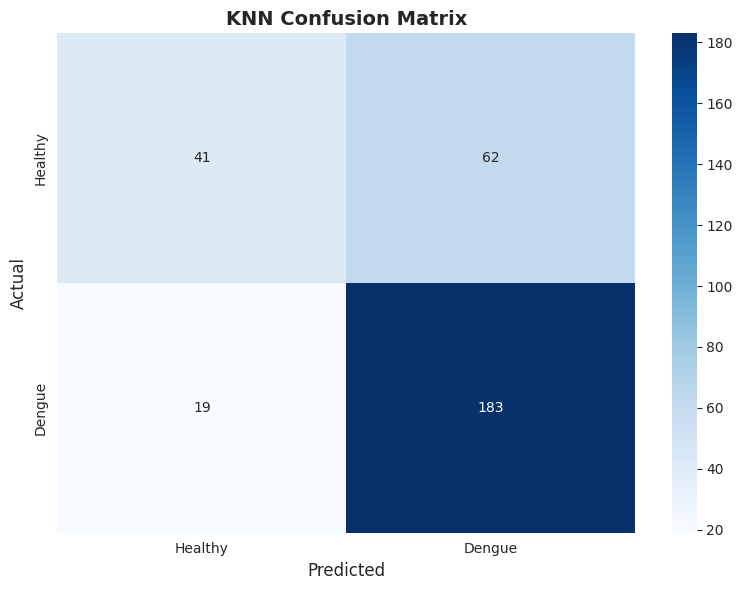

In [107]:
# Evaluation
print("\n📋 KNN Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_knn, target_names=['Healthy', 'Dengue']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Dengue'],
            yticklabels=['Healthy', 'Dengue'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)

## **Model- Decision Tree**

In [109]:
# Train Decision Tree
print("🌳 Training Decision Tree...\n")

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,          # Limit depth to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)  # No scaling needed
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("✅ Decision Tree trained!")
print(f"\n📊 Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

🌳 Training Decision Tree...

✅ Decision Tree trained!

📊 Decision Tree Accuracy: 0.7213 (72.13%)



📋 Decision Tree Classification Report:
              precision    recall  f1-score   support

     Healthy       0.70      0.30      0.42       103
      Dengue       0.72      0.94      0.82       202

    accuracy                           0.72       305
   macro avg       0.71      0.62      0.62       305
weighted avg       0.72      0.72      0.68       305



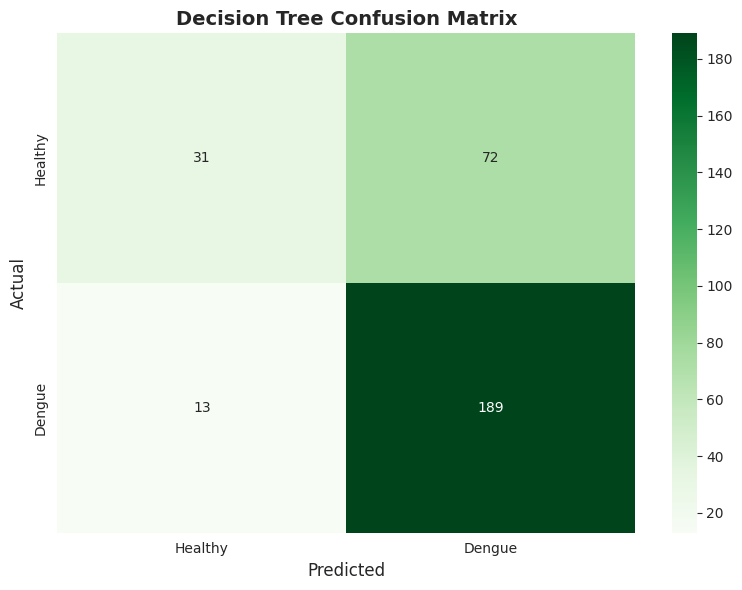

In [110]:
# Evaluation
print("\n📋 Decision Tree Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Healthy', 'Dengue']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Dengue'],
            yticklabels=['Healthy', 'Dengue'])
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Decision Tree):
                    Feature  Importance
Total Platelet Count(/cumm)    0.323019
             Neutrophils(%)    0.281977
                        RBC    0.174790
               Monocytes(%)    0.137953
                     PCT(%)    0.061570
                    MCH(pg)    0.015825
                    MCV(fl)    0.004866
                        Age    0.000000
           Hemoglobin(g/dl)    0.000000
             Eosinophils(%)    0.000000
                     HCT(%)    0.000000
                    MPV(fl)    0.000000
             Gender_encoded    0.000000


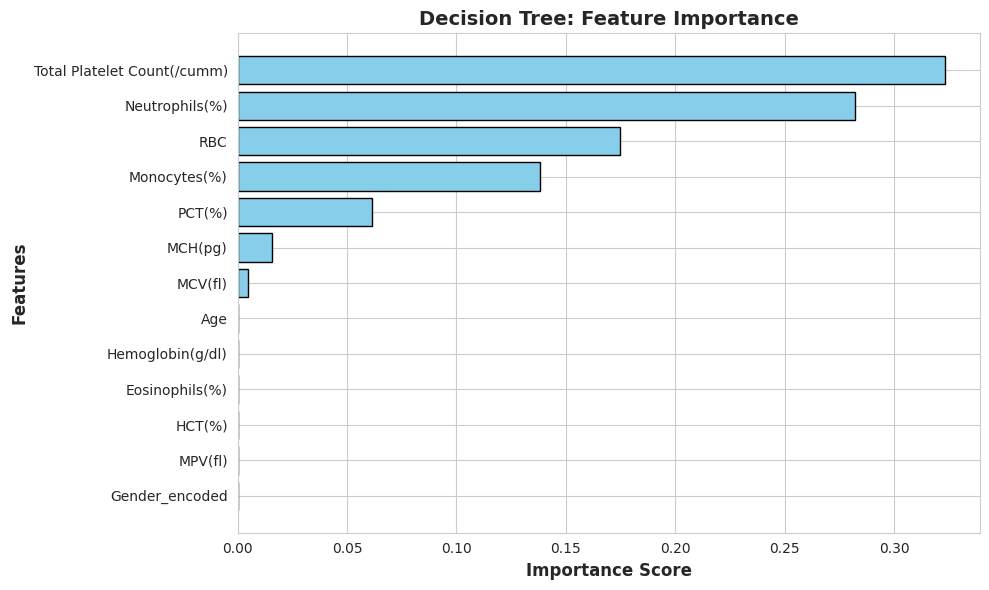


💡 These features are most important for prediction!



In [111]:
# Feature Importance
print("\n⭐ Feature Importance (Decision Tree):")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='skyblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 These features are most important for prediction!")
print("\n" + "="*60)

## **Model- Random Forest**

In [113]:
# Train Random Forest
print("🌲🌳🌲 Training Random Forest...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,     # 100 trees
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("✅ Random Forest trained!")
print(f"   → {rf_model.n_estimators} trees created")
print(f"   → Each tree votes")
print(f"\n📊 Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

🌲🌳🌲 Training Random Forest...

✅ Random Forest trained!
   → 100 trees created
   → Each tree votes

📊 Random Forest Accuracy: 0.7475 (74.75%)



📋 Random Forest Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.32      0.46       103
      Dengue       0.74      0.97      0.84       202

    accuracy                           0.75       305
   macro avg       0.78      0.64      0.65       305
weighted avg       0.77      0.75      0.71       305



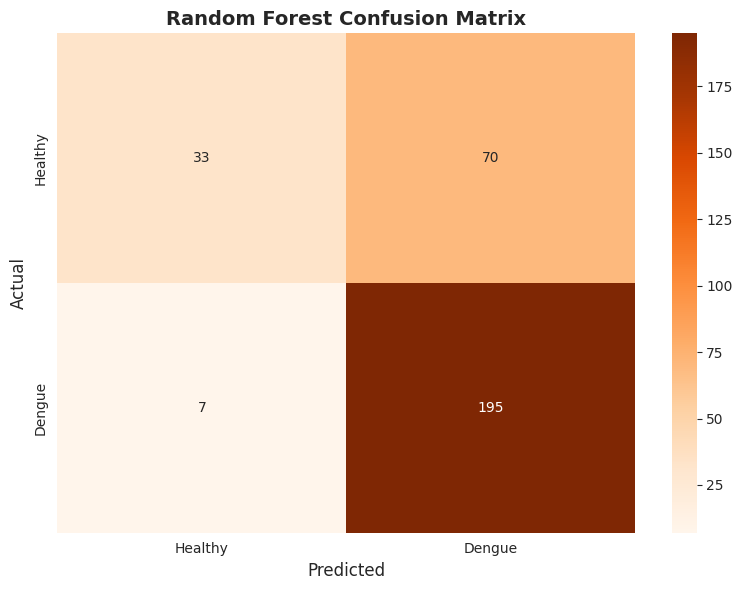

In [114]:
# Evaluation
print("\n📋 Random Forest Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Dengue']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Dengue'],
            yticklabels=['Healthy', 'Dengue'])
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Random Forest):
                    Feature  Importance
             Neutrophils(%)    0.197197
                     PCT(%)    0.134952
               Monocytes(%)    0.120169
Total Platelet Count(/cumm)    0.117498
                        RBC    0.100775
             Eosinophils(%)    0.099329
                    MPV(fl)    0.056989
                     HCT(%)    0.047707
           Hemoglobin(g/dl)    0.035822
                    MCH(pg)    0.035345
                    MCV(fl)    0.025306
                        Age    0.020265
             Gender_encoded    0.008646


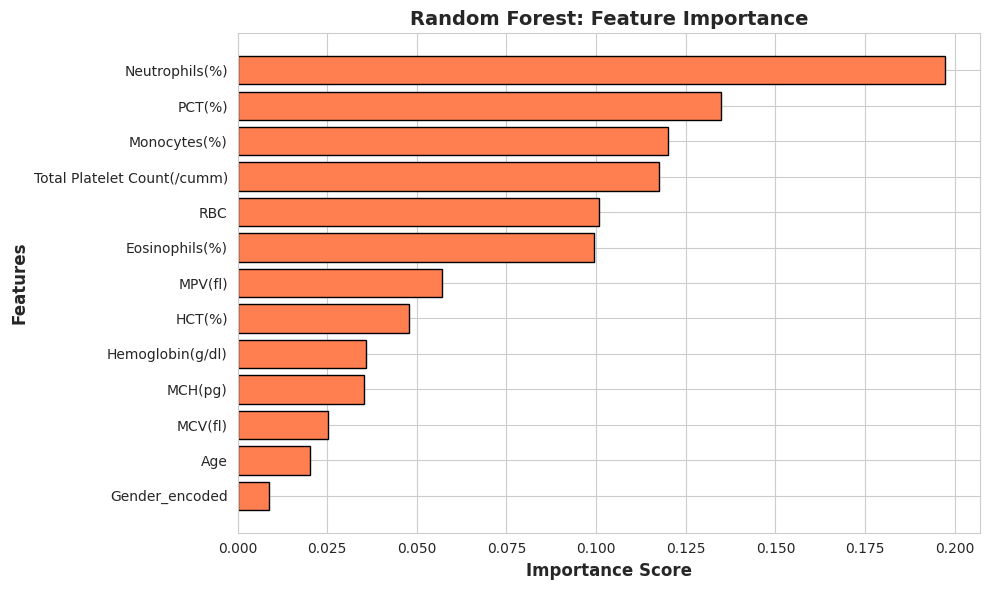


💡 Random Forest importance is more reliable!
   (Average of 100 trees)



In [115]:
# Feature Importance
print("\n⭐ Feature Importance (Random Forest):")
print("=" * 60)

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'],
         color='coral', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 Random Forest importance is more reliable!")
print("   (Average of 100 trees)")
print("\n" + "="*60)

In [116]:
# Compare all models
print("\n🏆 FINAL MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [knn_accuracy, dt_accuracy, rf_accuracy],
    'Accuracy %': [f"{knn_accuracy*100:.2f}%", f"{dt_accuracy*100:.2f}%", f"{rf_accuracy*100:.2f}%"]
})

comparison = comparison.sort_values('Accuracy', ascending=False)
print("\n" + comparison.to_string(index=False))

best_model = comparison.iloc[0]['Model']
best_acc = comparison.iloc[0]['Accuracy']

print(f"\n🥇 WINNER: {best_model}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("\n" + "="*60)


🏆 FINAL MODEL COMPARISON

        Model  Accuracy Accuracy %
Random Forest  0.747541     74.75%
          KNN  0.734426     73.44%
Decision Tree  0.721311     72.13%

🥇 WINNER: Random Forest
   Accuracy: 0.7475 (74.75%)



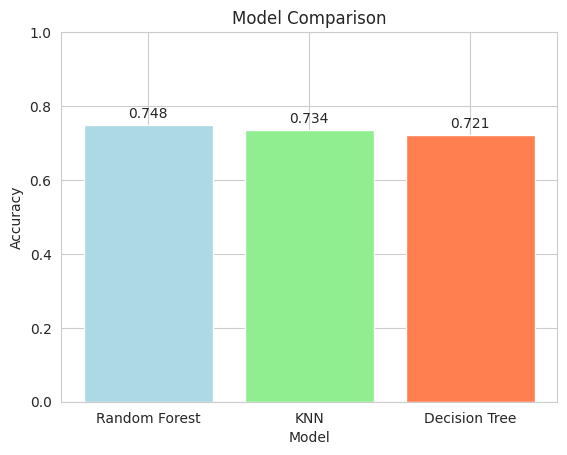

In [117]:
# Visual Comparison
plt.bar(comparison['Model'], comparison['Accuracy'], color=['lightblue', 'lightgreen', 'coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])

# Add values on bars
for i, acc in enumerate(comparison['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()

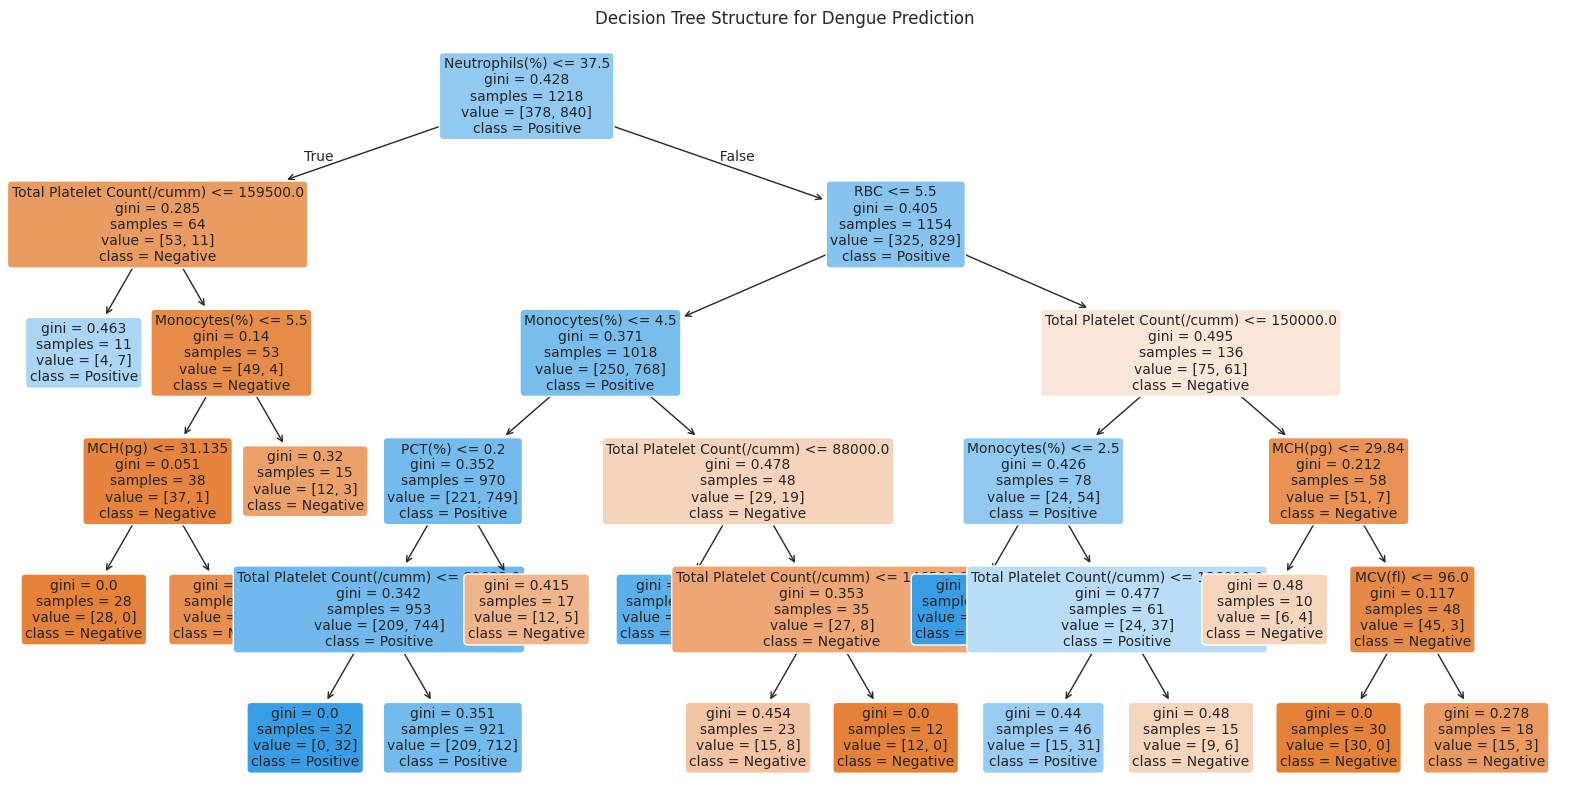

In [118]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Negative', 'Positive'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Structure for Dengue Prediction")
plt.show()

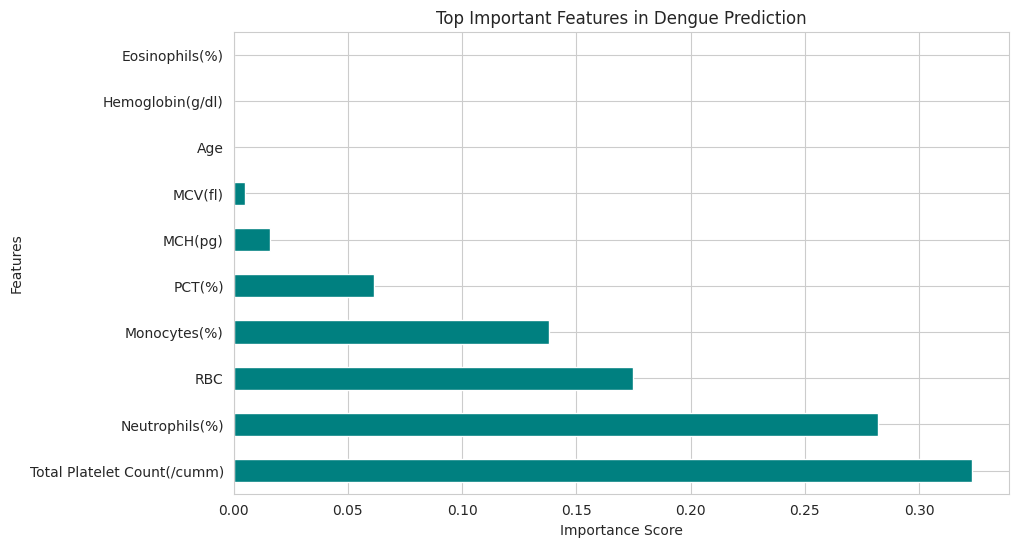

In [119]:
import pandas as pd

# ইম্পর্ট্যান্স ডাটা ফ্রেম তৈরি
feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)

# টপ ফিচারগুলো প্লট করা
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Important Features in Dengue Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [136]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

## **Confusion Matrix**

Confusion Matrix:
[[ 33  70]
 [  7 195]]

Correct: 228
Wrong: 77


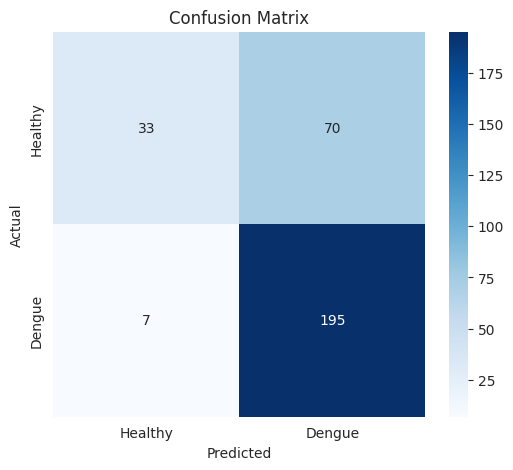

In [133]:
# Calculate confusion matrix
# Using y_pred_rf (Random Forest predictions) as it's the best performing model
cm = confusion_matrix(y_test, y_pred_rf)

# Print it
print("Confusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"Wrong: {cm[0,1] + cm[1,0]}")

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Dengue'],
            yticklabels=['Healthy', 'Dengue'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy:  0.75
Precision: 0.74
Recall:    0.97
F1-Score:  0.84


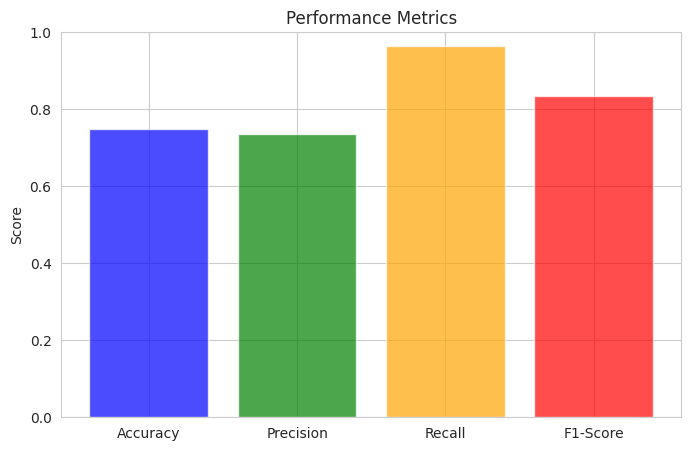

In [137]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

# Print them
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Simple bar chart
plt.figure(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()